## Access Satellite Ghrsst L3S 1Month Daynighttime Multi Sensor Southernocean (Zarr)
This Jupyter notebook demonstrates how to access and plot satellite_ghrsst_l3s_1month_daynighttime_multi_sensor_southernocean data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/579fc1ac-6ee5-40e2-9170-6a857e9b40da).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/satellite_ghrsst_l3s_1month_daynighttime_multi_sensor_southernocean.ipynb).


In [13]:
dataset_name = "satellite_ghrsst_l3s_1month_daynighttime_multi_sensor_southernocean"

## Install/Update packages and Load common functions

In [15]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.11.13 environment at: /Users/leo/Work/aodn_cloud_optimised/.venv
Resolved 205 packages in 107ms
Checked 205 packages in 3ms


✅ Local version 0.3.29 is up to date (remote: 0.3.29)


/Users/leo/Work/aodn_cloud_optimised/notebooks/DataQuery.py:4856: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


In [16]:
from DataQuery import GetAodn

# Understanding the Dataset

In [ ]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 176 ms, sys: 35.3 ms, total: 212 ms
Wall time: 889 ms


In [18]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	time = 79 ;
	lat = 2500 ;
	lon = 10000 ;

variables:
	float64 dt_analysis(time, lat, lon) ;
		dt_analysis:comment = The difference between this SST and the previous day's SST ;
		dt_analysis:long_name = deviation from last SST analysis ;
		dt_analysis:source = ABOM-L4LRfnd-GLOB-GAMSSA_28km ;
		dt_analysis:units = kelvin ;
		dt_analysis:valid_max = 127 ;
		dt_analysis:valid_min = -127 ;
	object filename(time) ;
	float64 l2p_flags(time, lat, lon) ;
		l2p_flags:comment = These flags are important to properly use the data.  Data not flagged as microwave are sourced from an infrared sensor. The lake and river flags are currently not set, but defined in GDS2.0r4. The aerosol flag indicates high aerosol concentration. The analysis flag indicates high difference from analysis temperatures (differences greater than Analysis Limit). The lowwind flag indicates regions of low wind speed (typically less than the low Wind Limit) per NWP model. The highwind flag indicate

## Plot time coverage

In [19]:
aodn_dataset.get_temporal_extent()

(Timestamp('2018-12-16 11:10:00'), Timestamp('2025-12-16 11:10:00'))

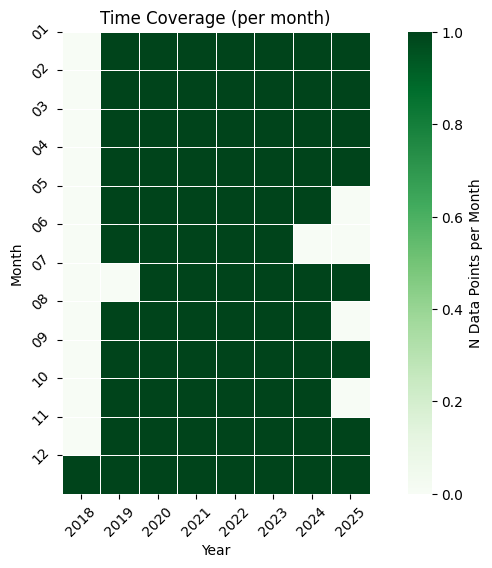

In [20]:
aodn_dataset.plot_time_coverage()

## Timeseries at a point

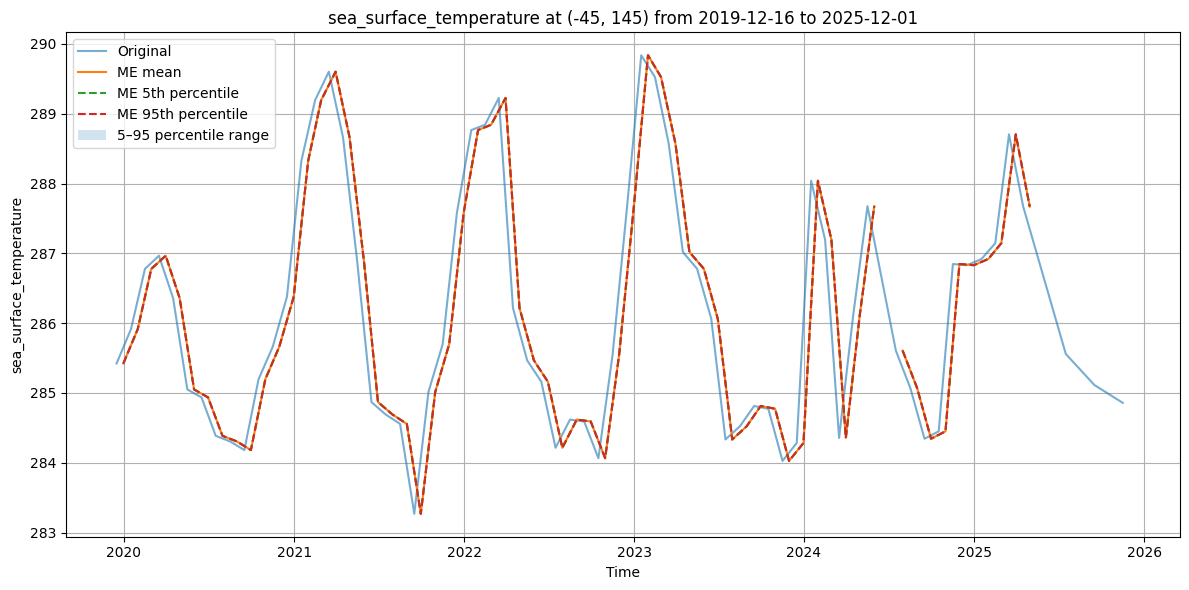

CPU times: user 1.36 s, sys: 482 ms, total: 1.85 s
Wall time: 30.6 s


In [27]:
%%time
time_series_df = aodn_dataset.get_timeseries_data(var_name='sea_surface_temperature', 
                                                  lat=-45, 
                                                  lon=145, 
                                                  date_start='2019-12-16', 
                                                  date_end='2025-12-01', 
                                                  lon_name_override="lon", 
                                                  lat_name_override="lat").plot_timeseries()

## Plot a gridded variable

2026-08-31 10:30:10,143 - aodn.GetAodn - INFO - Plotting 'sea surface foundation temperature' for 6 time steps.
/Users/leo/Work/aodn_cloud_optimised/notebooks/DataQuery.py:3934: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


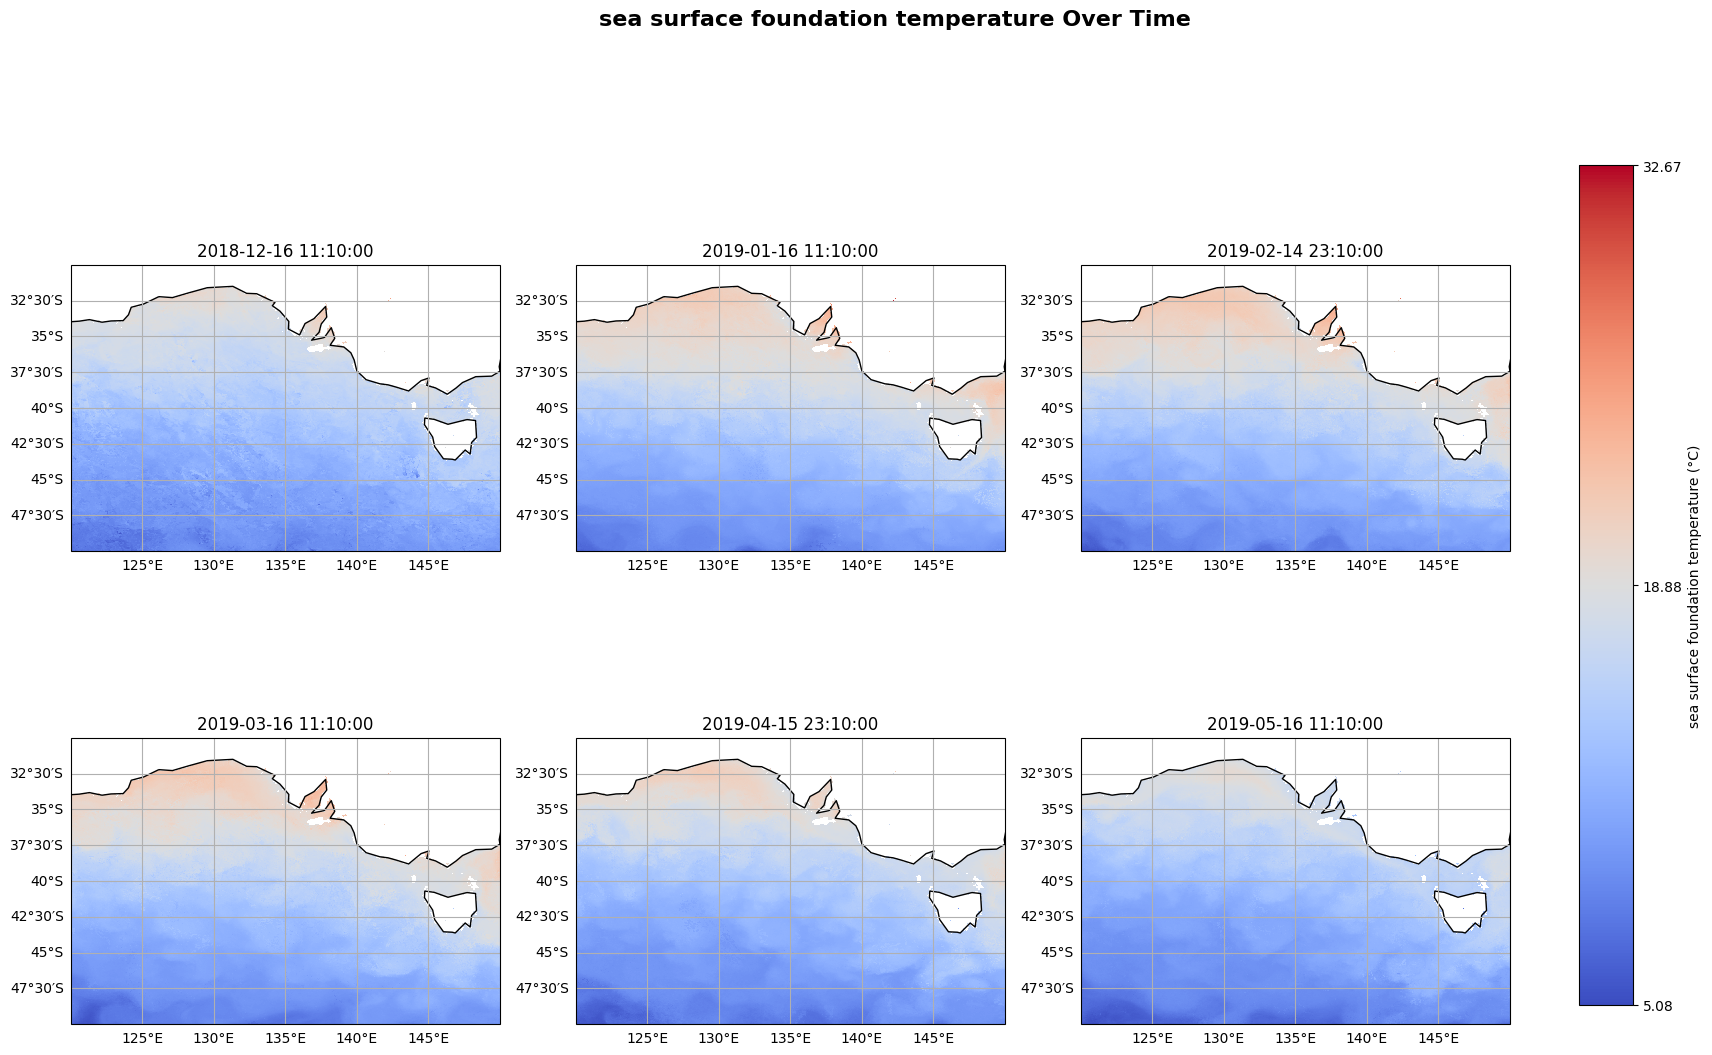

CPU times: user 6.31 s, sys: 417 ms, total: 6.73 s
Wall time: 21.9 s


In [23]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='sea_surface_temperature', 
                                                    date_start='2018-06-01',                                                
                                                    lon_name_override="lon", 
                                                    lat_name_override="lat", 
                                                    lon_slice=(120, 150), 
                                                    lat_slice=(-50, -30), 
                                                    n_days=6, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False)